<h1><center>Laboratorio 5: La desperación de Mr. Lepin 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Álvaro Sifuentes Tasayco
- Nombre de alumno 2: Sebastián Morales Castillo


---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores. 
- **Importante**: **¡Recuerden fijar semillas!** Así podemos reproducir sus resultados.

## Descripción del laboratorio.

### Importamos librerias utiles 😸

In [13]:
!uv add numpy pandas scikit-learn umap-learn plotly

Resolved 126 packages in 0.78ms
Checked 122 packages in 0.81ms


In [14]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.base import BaseEstimator, TransformerMixin


def plot_dim_reductions(
    pca_proj: np.ndarray,
    tsne_proj: np.ndarray,
    umap_proj: np.ndarray,
    name: None | str = None,
    colors: None | np.ndarray = None,
) -> go.Figure:
    fig = make_subplots(rows=1, cols=3, subplot_titles=("PCA", "t-SNE", "UMAP"))

    for i, (proj, title) in enumerate(zip([pca_proj, tsne_proj, umap_proj], ["PCA", "t-SNE", "UMAP"], strict=True)):
        temp_fig = px.scatter(
            x=proj[:, 0],
            y=proj[:, 1],
            color=colors.astype(str) if colors is not None else None,
            title=title,
            # showlegend=(i == 0),
        )

        for trace in temp_fig.data:
            trace.showlegend = i == 0
            fig.add_trace(trace, row=1, col=i + 1)

    fig.update_layout(height=400, width=1200, title_text=name)
    return fig

# Segmentación de Clientes en Tienda de Retail 🛍️

<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>

## 1.1 Cargar Dataset

Mr. Lepin, en una nueva reunión, le cuenta a ud y su equipo que los resultados derivados del análisis exploratorio de datos presentaron una gran utilidad para la empresa y que tiene un gran entusiasmo por continuar trabajando con ustedes.
Es por esto, que Mr. Lepin les pide que cargue y visualicen algunas de las filas que componen el Dataset.
A continuación un extracto de lo parlamentado en la reunión:

    - Usted: Es un gran logro para nuestro equipo que usted haya encontrado excelente el EDA. ¿Qué tiene en mente ahora?
    - Mr. Lepin: Resulta que hace algún tiempo, mientras tomaba un mojito en una reunión de gerentes en Panamá, oí a un *chato* acerca de **LRMFP**, que es un modelo que permite personificar a los clientes a través de la fabricación de distintos atributos que describen a los clientes. Lo encontré es-tu-pendo ñatito. 
    - Usted: Ehh bueno. Investigaremos acerca de este modelo y veremos lo que podemos hacer.

Por ende, su siguiente tarea es calcular **LRMFP** sobre cada cliente y luego hacer un análisis de las características generadas. Para esto, el área de ventas les entrega un nuevo archivo llamado `retail_dataset.pickle`, quien posee los datos del DataFrame original limpios y listos para obtener las características solicitadas por Mr. Lepin.

In [15]:
df_retail = pd.read_pickle(
    "https://github.com/MDS7202/MDS7202/raw/refs/heads/main/recursos/2026-01/labs/lab6/retail_dataset.pickle"
)
df_retail = df_retail.astype(
    {
        "Invoice": str,
        "StockCode": str,
        "Description": str,
        "Customer ID": str,
        "Country": str,
    }
)
df_retail.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1.2 Creación de nuevas Caracteristicas [2 Puntos] 

Como ya se les comentó, Mr. Lepin está interesado en obtener las características **LRMFP**, para esto les señala que estas características se construyen en base a las siguientes definiciones:

- **Length (L)**: Intervalo de tiempo, en días, entre la primera y la última visita del cliente. Mientras más grande sea el valor, más fiel es el cliente.

- **Recency (R)**: Indica hace cuánto tiempo el cliente realizó su última compra. Notar que para este caso, mientras más grande es el valor, menos interés posee el usuario para repetir una compra en uno de los locales.

- **Monetary (M)**: El término “monetario” se refiere a la cantidad media de dinero gastada por cada visita del cliente durante el período de observación y refleja la contribución del cliente a los ingresos de la empresa.

- **Frequency (F)**: Se refiere al número total de visitas del cliente durante el periodo de observación. Cuanto mayor sea la frecuencia, mayor será la fidelidad del cliente. 

- **Periodicity (P)**: Representa si los clientes visitan las tiendas con regularidad.

$$Periodicity(n)=std(IVT_1, ..., IVT_n)$$

&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Donde $IVT$ denota el tiempo entre visitas y n representa el número de valores de tiempo entre visitas de un cliente.
 

$$IVT_i=date\_diff(t_{i+1},t_i)$$

En base a las definiciones señaladas, diseñe una función que permita obtener las características **LRMFP** recibiendo un DataFrame como entrada. Para esto, no estará permitido el uso de iteradores; utilicen todas las herramientas que les ofrece `pandas` para realizar esto.

Una referencia que les puede ser útil es el [documento original](https://www.researchgate.net/publication/315979555_LRFMP_model_for_customer_segmentation_in_the_grocery_retail_industry_a_case_study) en donde se propone este método.

**<u>Formato</u> del Resultado Esperado:**

| Customer ID | Length | Recency | Frequency | Monetary | Periodicity |
|------------:|-------:|--------:|----------:|---------:|------------:|
|   12346.0   |    294 |      67 |        46 |   -64.68 |        37.0 |
|   12347.0   |     37 |       3 |        71 |  1323.32 |         0.0 |
|   12349.0   |    327 |      43 |       107 |  2646.99 |        78.0 |
|   12352.0   |     16 |      11 |        18 |   343.80 |         0.0 |
|   12356.0   |     44 |      16 |        84 |  3562.25 |        12.0 |

**Respuesta:**

In [ ]:
def custom_features(dataframe_in: pd.DataFrame) -> pd.DataFrame:
    dataframe_in = dataframe_in.copy()

    # Convertir InvoiceDate a tipo datetime
    dataframe_in["InvoiceDate"] = pd.to_datetime(dataframe_in["InvoiceDate"])

    # Crear ingreso por fila
    dataframe_in["Revenue"] = dataframe_in["Quantity"] * dataframe_in["Price"]

    # Calcular Length: intervalo de tiempo entre la primera y última compra de cada cliente
    length = dataframe_in.groupby("Customer ID")["InvoiceDate"].agg(["min", "max"])
    length["Length"] = (length["max"] - length["min"]).dt.days

    # Calcular Recency:
    fecha_referencia = dataframe_in["InvoiceDate"].max() + pd.Timedelta(days=1)
    recency_series = dataframe_in.groupby("Customer ID")["InvoiceDate"].max()
    recency_series = (fecha_referencia - recency_series).dt.days
    recency = recency_series.to_frame(name="Recency")

    # Calcular Frequency:
    frequency_series = dataframe_in.groupby("Customer ID")["Invoice"].nunique()
    frequency = frequency_series.to_frame(name="Frequency")

    # Calcular Monetary:
    monetary_series = dataframe_in.groupby("Customer ID")["Revenue"].sum() / frequency_series
    monetary = monetary_series.to_frame(name="Monetary")

    # Calcular Periodicity: desviación estándar de los tiempos entre visitas
    dataframe_in = dataframe_in.sort_values(["Customer ID", "InvoiceDate"])
    dataframe_in["IVT"] = dataframe_in.groupby("Customer ID")["InvoiceDate"].diff().dt.days
    periodicity = dataframe_in.groupby("Customer ID")["IVT"].std().fillna(0)
    periodicity = pd.DataFrame(periodicity, columns=["Periodicity"])

    # Combinar todo en un solo DataFrame
    features_df = pd.concat(
        [length["Length"], recency, frequency, monetary, periodicity],
        axis=1,
    )

    return features_df.fillna(0)


# Ejemplo de cómo usar la función con el DataFrame 'df_retail'
customer_features = custom_features(df_retail)
customer_features.head()

,Length,Recency,Frequency,Monetary,Periodicity
12346.0,196,165,11,33.896364,0
12347.0,37,3,2,661.660000,0
12348.0,0,74,1,222.160000,0
12349.0,181,43,3,890.380000,0
12351.0,0,11,1,300.930000,0


## 1.3 Pipelines 👷

Finalmente *Mr. Lepin* le pregunta si sería posible realizar un pipeline para realizar una segmentación de los clientes con los nuevos datos generados, a lo que usted responde que **sí** y propone la utilización de k-means para la segmentación.

A continuación siga los pasos requeridos para obtener la segmentación de clientes.

### 1.3.1 Estandarizar Caracteristicas [0.5 puntos]

Construya una clase llamada ``MinMax()`` utilizando ``BaseEstimator`` y ``TransformerMixin`` para realizar una transformación de cada una de las columnas de un DataFrame utilizando ``ColumnTransformer()`` más tarde (tome como referencia el siguiente [enlace](https://sklearn-template.readthedocs.io/en/latest/user_guide.html#transformer)).


 Para esto considere que Min-Max escaler queda dada por la ecuación:

$$MinMax = \dfrac{x-min(x)}{max(x) - min(x)}$$

Con esto buscamos que los valores que componen a las columnas se muevan en el rango de valores $[0, 1]$.

**Respuesta:**

In [17]:
import numpy as np
import pandas as pd


class MinMax(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X).astype(float)

        self.min_ = X.min()
        self.max_ = X.max()
        self.range_ = self.max_ - self.min_

        self.range_ = self.range_.replace(0, 1)

        return self

    def transform(self, X):
        X = pd.DataFrame(X).astype(float)

        X_scaled = (X - self.min_) / self.range_

        return X_scaled.replace([np.inf, -np.inf], 0).fillna(0)

### 1.3.2 Pipelines de Proyecciones [0.5 puntos]

Para comparar técnicas de reducción de dimensionalidad, realice **tres pipelines** distintos sobre los datos **LRMFP** usando los siguientes métodos:
- **PCA**
- **t-SNE**
- **UMAP**

Para cada pipeline, siga estos pasos:
1. Obtenga las características **LRMFP** desde el DataFrame `retail_dataset.pickle` utilizando la función ``custom_features`` creada anteriormente, junto a ``FunctionTransformer()``. Considere esto como el primer paso de su pipeline.
2. En segundo lugar, usando ``ColumnTransformer()``, aplique el MinMax scaler creado por usted sobre todas las columnas generadas en el paso anterior.
3. Finalmente, aplique el método de reducción de dimensionalidad correspondiente (PCA, t-SNE o UMAP) para obtener las 2 componentes más relevantes.

A continuación, grafique las proyecciones obtenidas de las tres técnicas en una sola figura comparativa.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from umap import UMAP

lrmfp_columns = ["Length", "Recency", "Frequency", "Monetary", "Periodicity"]

features_transformer = FunctionTransformer(custom_features, validate=False)

scaler_transformer = ColumnTransformer(
    transformers=[
        ("minmax", MinMax(), lrmfp_columns),
    ],
    remainder="drop",
)

pipeline_pca = Pipeline(
    steps=[
        ("features", features_transformer),
        ("scaler", scaler_transformer),
        ("pca", PCA(n_components=2, random_state=42)),
    ]
)

pipeline_tsne = Pipeline(
    steps=[
        ("features", features_transformer),
        ("scaler", scaler_transformer),
        (
            "tsne",
            TSNE(
                n_components=2,
                random_state=42,
                init="random",
                learning_rate="auto",
            ),
        ),
    ]
)

pipeline_umap = Pipeline(
    steps=[
        ("features", features_transformer),
        ("scaler", scaler_transformer),
        ("umap", UMAP(n_components=2, random_state=42)),
    ]
)

**Respuesta:**

In [19]:
# Utilice este código para ejecutar las pipelines y graficar.

pca_proj = pipeline_pca.fit_transform(df_retail)
tsne_proj = pipeline_tsne.fit_transform(df_retail)
umap_proj = pipeline_umap.fit_transform(df_retail)

fig = plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="Reducción de Dimensionalidad", colors=None)
fig.show()

/home/sebastianmorales/Documentos/uchile/lab_prog_datos/MDS7202/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### 1.3.3 Análisis de los Loadings de PCA [0.5 puntos]
Antes de continuar con la etapa de clustering, analice los *loadings* (pesos o coeficientes) de las componentes principales obtenidas con PCA. 

Utilice el siguiente tutorial para visualizarlos: https://plotly.com/python/pca-visualization/

- Calcule y reporte los *loadings* de las dos primeras componentes principales.
- Interprete qué características (**LRMFP**) son más relevantes en cada componente.
- Visualice los *loadings* usando un gráfico de barras para cada componente.



In [20]:
# Obtener el modelo PCA desde el pipeline
pca_model = pipeline_pca.named_steps["pca"]

# Obtener los loadings
loadings = pca_model.components_

# Nombres de variables
features = ["Length", "Recency", "Frequency", "Monetary", "Periodicity"]

In [21]:
import plotly.graph_objects as go

fig = go.Figure()

# Componente 1
fig.add_trace(go.Bar(x=features, y=loadings[0], name="Componente 1"))

# Componente 2
fig.add_trace(go.Bar(x=features, y=loadings[1], name="Componente 2"))

fig.update_layout(title="Loadings de PCA", xaxis_title="Variables LRMFP", yaxis_title="Peso", barmode="group")

fig.show()

### Preguntas sobre loadings:

- ¿Qué son los loadings de PCA?

> Respuesta: Los loadings de PCA corresponden a los coeficientes que indican la contribución de cada variable original en la construcción de las componentes principales. Estos permiten identificar qué variables explican la mayor parte de la variabilidad de los datos.

- ¿Qué información relevante obtiene sobre la estructura de los datos a partir de los *loadings* de PCA?

> Respuesta: A partir de los loadings se observa que la primera componente principal está dominada casi exclusivamente por la variable Length, mientras que la segunda componente está dominada por la variable Monetary. Lo que indica que la variabilidad de los datos está principalmente explicada por la duración de la relación del cliente con la empresa y por su nivel de gasto.

- ¿Existe alguna relación interesante entre las direcciones de las variables?

> Respuesta: Sí, se observa que las variables Length y Monetary dominan distintas componentes principales, lo que sugiere que representan dimensiones independientes del comportamiento del cliente. En cambio, variables como Recency, Frequency y Periodicity tienen una contribución muy baja en ambas componentes, indicando que tienen menor relevancia en la estructura global de los datos.

## 1.4 Clustering

### 1.4.1 Método del Codo [0.5 puntos]

Utilizando la clase creada para escalamiento, aplique el método del codo para visualizar cuál es el número de clusters que mejor se ajustan a los datos. Realice esto utilizando el algoritmo K-means dentro de un pipeline para un $k \in [1,20]$, donde k representa el número de clusters del k-means. Para la realización de esta sección y la próxima (1.4.2), considere los mismos pasos utilizados para el t-SNE, pero **permutando el algoritmo de reducción de dimensionalidad por k-means.**

**Respuesta:**

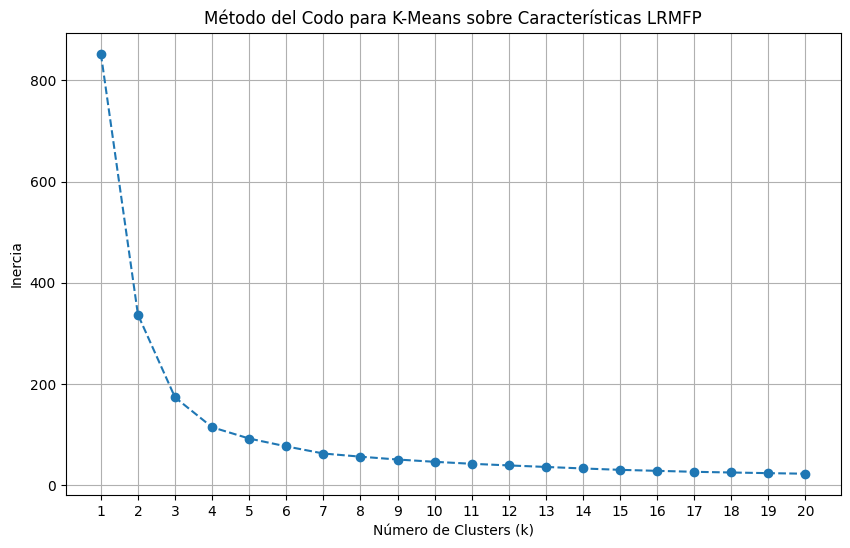

In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inercias = []
rango_k = range(1, 21)

for k in rango_k:
    pipeline_kmeans = Pipeline(
        steps=[
            ("features", features_transformer),
            ("scaler", scaler_transformer),
            ("kmeans", KMeans(n_clusters=k, random_state=42, n_init=10)),
        ]
    )
    pipeline_kmeans.fit(df_retail)
    # Extraemos la inercia del estimador K-Means ajustado
    kmeans_model = pipeline_kmeans.named_steps["kmeans"]
    inercias.append(kmeans_model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercias, marker="o", linestyle="--")
plt.title("Método del Codo para K-Means sobre Características LRMFP")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia")
plt.xticks(rango_k)
plt.grid(True)
plt.show()

### Preguntas Método del Codo

- A través del gráfico obtenido, comente y justifique qué valor de k escogería para realizar el k-means.

> Respuesta: ...

- Le fue útil el método del codo para encontrar el número de clusters?

> Respuesta: ...

- Si no fue así, ¿qué otros métodos podría haber usado para encontrar un número óptimo de clusters?

> Respuesta: ...

### 1.4.2 Segmentación de Clientes con K-Means 🎁 [1 punto]

Por último, Mr. Lepin, impaciente de no entender lo que usted intenta explicarle, le solicita que por favor muestre algún resultado "visual y entendible" de los grupos encontrados.

En base a la elección de k realizada en la sección anterior, utilice este valor escogido y entrene un modelo de K-means utilizando el mismo pipeline de scikit-learn utilizado anteriormente.

Una vez ajustado los datos, genere una tabla con los promedios (o medianas) para cada uno de los atributos, agrupando estos por el clúster que pertenecen.

Finalmente, construya un heatmap de las características promedio de cada cluster para visualizar y comparar los perfiles de los grupos.

**Estadísticas de Referencia para K=6:**

Ud. debe calcularlas - Varían de ejecución en ejecución.


|         | Length  | Recency   | Frequency | Monetary | Periodicity |       |
|---------|---------|-----------|----------|-------------|-------|-------|
| Cluster |         |           |          |             |       |       |
|    0    |   258.8 |      45.2 |     76.1 |      1107.7 | 107.6 |   449 |
|    1    |    76.1 |     217.6 |     45.5 |       791.7 |  14.1 |   466 |
|    2    |   368.5 |       4.8 |   2715.0 |    226621.6 |   4.2 |     4 |
|    3    |    85.3 |      45.7 |     65.8 |      1047.0 |  10.5 |   987 |
|    4    |   347.2 |      15.9 |   1658.0 |     35829.3 |   8.0 |    25 |
|    5    |   298.0 |      29.8 |    183.8 |      3639.9 |  32.0 |  1188 |

In [23]:
# Aquí calcule K-Means
...

kmeans_labels = ""

In [24]:
# Utilice la siguiente función para graficar k-means. kmeans_labels = clusters obtenidos por k-means.
plot_dim_reductions(pca_proj, tsne_proj, umap_proj, name="KMeans K=6", colors=kmeans_labels)

AttributeError: 'str' object has no attribute 'astype'

In [ ]:
# Aquí grafique el Heatmap
...

### Preguntas sobre K-Means: 

- ¿Se separaron bien los distintos clusters en cada visualización? 

> Respuesta: ...

- ¿Es posible observar agrupaciones coherentes?

> Respuesta: ...

- ¿Quedarían mejor más o menos clusters?

> Respuesta: ...

- ¿K-Means, dada la forma de las proyecciones, será el mejor método para clusterizar este dataset?¿Habrá algún otro mejor?

> Respuesta: ...

Y por último:

- Nombre a cada uno de los clusters según el comportamiento de sus miembros (ej. "C1: Compran poco pero con gran valor...") - Si es necesario, ajuste el número de clusters antes de responder.

> Respuestas: ...


Justifique su respuesta y no decepcione a Mr. Lepin.

## 1.5 Detección de Anomalías con DBSCAN [1 punto]
En esta sección, utilizará el algoritmo DBSCAN para identificar posibles anomalías (outliers) en los clientes del retail.

- Puede aplicar DBSCAN sobre las características originales escaladas (**LRMFP**) o sobre alguna de las proyecciones 2D (PCA, t-SNE o UMAP). Justifique su elección en las preguntas al final de la sección.
- Visualice los resultados usando `plot_dim_reductions`, mostrando los clusters y resaltando los outliers (label = -1) en las tres proyecciones (PCA, t-SNE, UMAP).

In [ ]:
from sklearn.cluster import DBSCAN, dbscan  # noqa: F401

dbscan_labels = ""

In [ ]:
# Utilice este código para graficar. dbscan_labels = clusters/outliers obtenidos por DBSCAN.
fig_dbscan = plot_dim_reductions(
    pca_proj,
    tsne_proj,
    umap_proj,
    name="DBSCAN - Detección de Anomalías",
    colors=dbscan_labels,
)
fig_dbscan.show()

### Preguntas sobre DBSCAN


1. ¿Por qué decidiste usar los datos originales completos o las proyecciones para aplicar DBSCAN? ¿Por qué no usaste la otra opción?

> Respuesta: ...

2. ¿Cómo elegiste los parámetros de DBSCAN (`eps`, `min_samples`)? ¿Probaste diferentes valores? ¿Cómo afectó esto los resultados?

> Respuesta: ...

3. ¿Tienen sentido los outliers encontrados según el contexto del negocio? ¿Qué interpretación le das a estos clientes? Analiza los datos con pandas si es necesario.

> Respuesta: ...

# Conclusión
Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por correo, Discord o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>